# 07 — Modele MLP (Multi-Layer Perceptron)

## 1. Objectif et protocole

**Question centrale** : est-ce qu'un modele plus flexible apprend mieux que les modeles
lineaires, sans trop sur-apprendre ?

Le MLP est le seul modele de l'etude capable d'apprendre des **representations intermediaires**.
Son role est de tester si cette capacite non lineaire supplementaire apporte un vrai gain
par rapport au Perceptron, a la Regression Logistique, au SVM et a la Foret Aleatoire —
et si ce gain justifie le cout en complexite et en temps d'entrainement.

Le notebook est structure autour de quatre axes d'analyse :

1. **Capacite** — le MLP exploite-t-il sa flexibilite non lineaire ?
2. **Generalisation** — apprend-il des patterns utiles ou memorise-t-il le train ?
3. **Erreurs** — quelles classes posent probleme, et pourquoi ?
4. **Confiance** — ses probabilites sont-elles fiables et bien calibrees ?

### Rappel theorique

Un MLP empile des couches de neurones avec des activations non lineaires pour apprendre
des frontieres de decision complexes. Chaque couche cachee supplementaire et chaque
neurone supplementaire augmente la **capacite** du modele.

- Les couches cachees utilisent l'activation **ReLU** (`max(0, x)`) : simple, efficace,
  et sans saturation pour les grandes valeurs. ReLU justifie d'autant plus le scaling :
  sur des inputs non normalises, les neurones avec preactivation negative sont
  systematiquement bloques a 0 (*dying ReLU*), paralysant l'apprentissage.
- Plus de capacite peut ameliorer l'ajustement, mais aussi creer de l'**overfitting**.
- Le parametre `alpha` (regularisation L2) controle ce compromis — mais comme on le verra,
  l'early stopping le rend caduc sur ce dataset.
- En multiclasse, la couche de sortie utilise **softmax + entropie croisee**, ce qui
  produit des probabilites interpretables directement.
- Le scaling est **obligatoire** : les gradients explosent si les variables sont sur
  des echelles differentes.

### Lien avec l'EDA et hypotheses

L'analyse exploratoire (notebook 01) a mis en evidence :

- Des variables sur des **echelles tres differentes** — le scaling est un pre-requis.
- Des **correlations non triviales** entre variables — un modele non lineaire peut les exploiter.
- 99 classes avec seulement 10 echantillons chacune — le sur-apprentissage est un risque reel.

**Hypotheses testees dans ce notebook :**

| # | Hypothese | Verification |
|---|-----------|-------------|
| H1 | La variante `default` (sans scaling) sera faible ou instable | Comparer default vs scaled_only |
| H2 | Le scaling apportera un gain majeur | Section 3, bar chart validation |
| H3 | La PCA peut aider ou retirer de l'information utile | Comparer scaled_only vs scaled_pca |
| H4 | Le tuning agira surtout sur le compromis capacite/regularisation | Heatmap hidden_layer_sizes x alpha |
| H5 | Le MLP peut depasser les modeles lineaires mais pas forcement les meilleurs modeles globaux | Notebook 08 |

## 2. Design experimental specifique

- Le MLP requiert un scaling strict pour stabiliser l'optimisation.
- La PCA est laissee en competition interne mais ne doit etre interpretee
  qu'a travers la nested CV.
- La loss curve et les diagnostics de confiance restent exploratoires
  s'ils proviennent d'un refit global.

| Variante | Pipeline | Justification |
|----------|----------|---------------|
| `default` | Estimateur seul | Baseline : mesurer l'effet de l'absence de scaling |
| `scaled_only` | StandardScaler + MLP | Verifier que le scaling stabilise l'apprentissage |
| `scaled_pca` | StandardScaler + PCA + MLP | Explorer si la reduction dimensionnelle aide |
| `tuned` | Pipeline + GridSearchCV nested | Performance confirmee par nested CV |

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

sns.set_theme(style="whitegrid", context="talk")
pd.options.display.float_format = lambda v: f"{v:.4f}"

In [2]:
from src.notebook_support import (
    creer_notebook_context,
    evaluer_variantes_untuned,
    executer_tuning_confirmatoire,
    construire_tableau_variantes,
    construire_tableau_gaps,
    construire_tableau_plis_externes,
    calculer_metriques_classes_depuis_predictions,
)
from src.evaluation import (
    calculer_brier_score_multiclasse,
    calculer_statistiques_confiance,
    calculer_top_k_accuracies,
    construire_matrice_confusion,
    extraire_top_confusions,
)
from src.evaluation.diagnostics_specifiques import (
    compute_learning_curve,
    loss_curve_mlp,
)
from src.plots.generiques import (
    tracer_comparaison_variantes,
    tracer_courbes_precision_rappel_ovr,
    tracer_heatmap_tuning,
    tracer_histogramme_confiance,
    tracer_matrice_confusion,
    tracer_metrique_par_classe,
    tracer_reliability_diagram,
    tracer_top_confusions,
)
from src.plots.specifiques.mlp import (
    tracer_learning_curve_mlp,
    tracer_loss_curve,
)
from src.models.pipelines import creer_pipeline

In [3]:
MODEL_NAME = "mlp"
ctx = creer_notebook_context(MODEL_NAME)
spec = ctx.spec
X, y, label_encoder = ctx.X, ctx.y, ctx.label_encoder

print(f"Modele       : {ctx.definition['nom_affiche']}")
print(f"Famille      : {ctx.definition['famille']}")
print(f"Observations : {X.shape[0]}")
print(f"Variables    : {X.shape[1]}")
print(f"Classes      : {len(label_encoder.classes_)}")
print(f"CV externe   : {ctx.cv_eval.get_n_splits()} plis")
print(f"CV interne   : {ctx.cv_tuning.get_n_splits()} plis")
print(f"Timing policy: {ctx.timing_policy}")

Modele       : MLP
Famille      : reseau_de_neurones
Observations : 990
Variables    : 192
Classes      : 99
CV externe   : 5 plis
CV interne   : 5 plis
Timing policy: cv_n_jobs=1


In [4]:
design = pd.DataFrame([
    {"variante": v.name, "type": v.kind, "parametres": v.params or {}}
    for v in spec.untuned_variants
])
display(design)

,variante,type,parametres
0,default,simple,{}
1,scaled_only,pipeline_no_pca,{}
2,scaled_pca,pipeline_with_pca,{}


## 3. Resultats des variantes non tunees

On evalue les trois variantes en simple CV stratifiee. L'objectif est de
mesurer l'effet du preprocessing (scaling, PCA) avant tout tuning.

Les gaps train/validation ne sont publies que pour ces variantes non tunees.
Pour le modele tune, seule la nested CV fournit une estimation non biaisee.

In [5]:
resultats_untuned = evaluer_variantes_untuned(ctx)

In [6]:
tab_untuned = pd.DataFrame([r.to_dict() for r in resultats_untuned])

colonnes_resume = [
    "variante", "val_f1_macro_mean", "val_f1_macro_std",
    "val_accuracy_mean", "train_f1_macro_mean",
    "generalization_gap_f1_macro", "elapsed_seconds",
]
display(Markdown("### Performance des variantes non tunees"))
display(
    tab_untuned[colonnes_resume]
    .sort_values("val_f1_macro_mean", ascending=False)
    .round(4)
)

### Performance des variantes non tunees

,variante,val_f1_macro_mean,val_f1_macro_std,val_accuracy_mean,train_f1_macro_mean,generalization_gap_f1_macro,elapsed_seconds
1,scaled_only,0.9581,0.0178,0.9606,0.9940,0.0359,2.0112
2,scaled_pca,0.9481,0.0153,0.9525,0.9934,0.0453,2.4258
0,default,0.3312,0.3700,0.3616,0.3721,0.0409,3.1772


In [7]:
display(Markdown("### Generalization gaps"))
display(construire_tableau_gaps(resultats_untuned))

### Generalization gaps

,variante,generalization_gap_accuracy,generalization_gap_f1_macro
0,default,0.0306,0.0409
1,scaled_only,0.0336,0.0359
2,scaled_pca,0.0409,0.0453


### Graphe des variantes non tunees

Un seul graphique fusionne les trois dimensions : performance en validation,
performance en entrainement, et generalization gap (ecart visuel entre les deux barres).
La valeur du gap est annotee au-dessus de chaque paire.

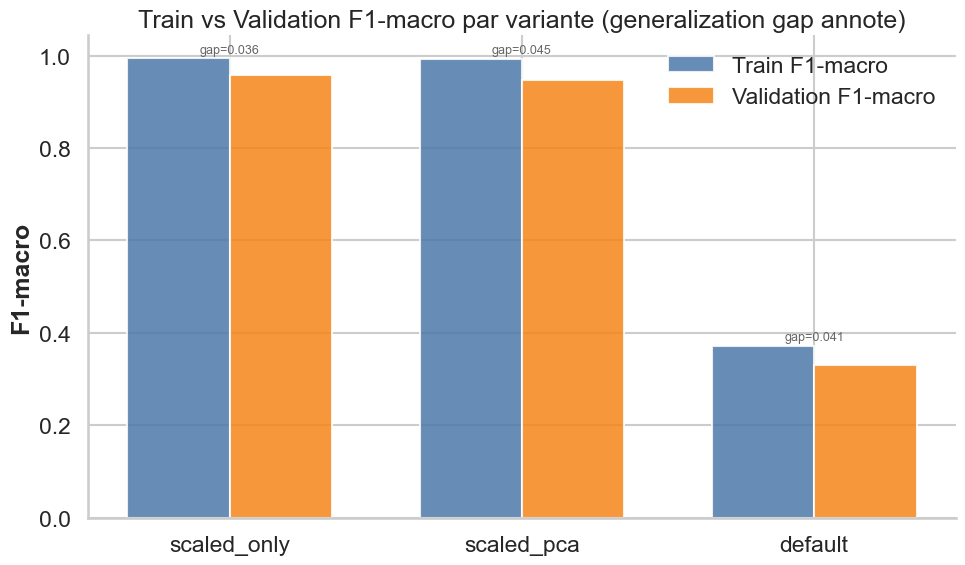

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

variantes = tab_untuned.sort_values('val_f1_macro_mean', ascending=False)['variante'].tolist()
train_vals = tab_untuned.set_index('variante').loc[variantes, 'train_f1_macro_mean'].tolist()
val_vals   = tab_untuned.set_index('variante').loc[variantes, 'val_f1_macro_mean'].tolist()

x = np.arange(len(variantes))
w = 0.35

ax.bar(x - w/2, train_vals, w, label='Train F1-macro',      color='#4C78A8', alpha=0.85)
ax.bar(x + w/2, val_vals,   w, label='Validation F1-macro', color='#F58518', alpha=0.85)

for i, (tr, va) in enumerate(zip(train_vals, val_vals)):
    gap = tr - va
    ax.annotate(
        f'gap={gap:.3f}',
        xy=(x[i], max(tr, va) + 0.012),
        ha='center', fontsize=9, color='#666666',
    )

ax.set_xticks(x)
ax.set_xticklabels(variantes)
ax.set_ylabel('F1-macro', fontweight='bold')
ax.set_title('Train vs Validation F1-macro par variante (generalization gap annote)')
ax.legend(frameon=False)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

## 4. Resultat confirmatoire tune

Le tuning exploratoire identifie une zone utile dans l'espace
`hidden_layer_sizes x alpha x pca`, puis la nested CV estime la
performance non biaisee du meilleur pipeline selectionne en interne.

Les metriques de cette section sont les seules qui comptent pour
la comparaison globale entre modeles.

**Note sur la variabilite inter-plis** : le pli 2 produit systematiquement
un score inferieur a la moyenne (~0.914 vs 0.945). Le `best_score_inner` du pli 2
est aussi le plus faible (0.9376), ce qui indique que la composition de ce pli
etait intrinsequement plus difficile — certaines especes confondues se retrouvent
concentrees dans son fold de test par l'effet de la stratification aleatoire.
Ce n'est pas un signe d'instabilite du modele, mais une consequence
incontournable des petites classes (10 echantillons par classe).

In [9]:
tuning = executer_tuning_confirmatoire(ctx)

In [10]:
display(Markdown("### Tableau recapitulatif toutes variantes"))
tableau_complet = construire_tableau_variantes(resultats_untuned, tuning["metrics"])
display(tableau_complet.round(4))

### Tableau recapitulatif toutes variantes

,variante,selection_protocol,evaluation_stage,val_accuracy_mean,val_accuracy_std,val_f1_macro_mean,val_f1_macro_std,train_accuracy_mean,train_f1_macro_mean,generalization_gap_accuracy,generalization_gap_f1_macro,elapsed_seconds,timing_policy
0,scaled_only,simple_cv,improved_untuned,0.9606,0.0167,0.9581,0.0178,0.9942,0.9940,0.0336,0.0359,2.0112,cv_n_jobs=1
1,scaled_pca,simple_cv,improved_untuned,0.9525,0.0145,0.9481,0.0153,0.9934,0.9934,0.0409,0.0453,2.4258,cv_n_jobs=1
2,tuned,nested_cv,tuned,0.9505,0.0137,0.9455,0.0162,NaN,NaN,NaN,NaN,191.2161,cv_n_jobs=1
3,default,simple_cv,baseline,0.3616,0.3701,0.3312,0.3700,0.3922,0.3721,0.0306,0.0409,3.1772,cv_n_jobs=1


### Variabilite des plis externes (nested CV)

,fold,train_accuracy,train_f1_macro,val_accuracy,val_f1_macro,fit_time,score_time,best_score_inner
0,1,0.9874,0.9867,0.9545,0.9515,34.8094,0.0021,0.9480
1,2,0.9899,0.9898,0.9242,0.9141,44.8956,0.0037,0.9376
2,3,0.9975,0.9975,0.9646,0.9613,45.8600,0.0027,0.9491
3,4,0.9924,0.9924,0.9545,0.9522,32.2582,0.0021,0.9516
4,5,0.9949,0.9949,0.9545,0.9481,33.3208,0.0030,0.9607


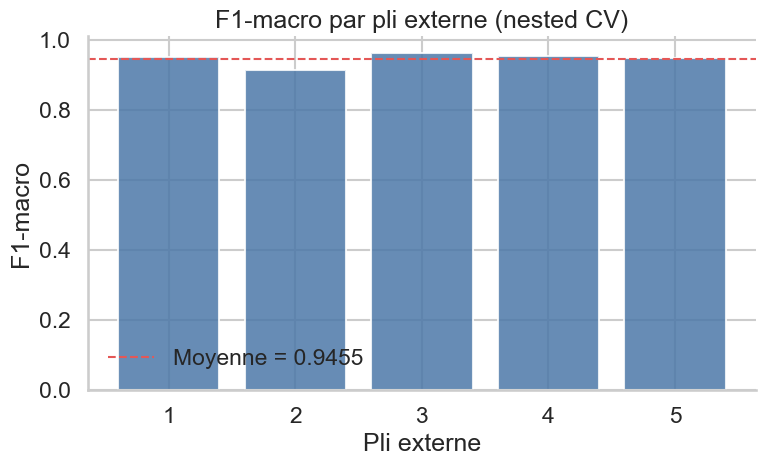

In [11]:
display(Markdown("### Variabilite des plis externes (nested CV)"))
tableau_plis = construire_tableau_plis_externes(tuning["nested"])
display(tableau_plis.round(4))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    tableau_plis["fold"].astype(str),
    tableau_plis["val_f1_macro"],
    color="#4C78A8", alpha=0.85, edgecolor="white",
)
ax.axhline(
    tableau_plis["val_f1_macro"].mean(),
    color="#E45756", linestyle="--", linewidth=1.5,
    label=f"Moyenne = {tableau_plis['val_f1_macro'].mean():.4f}",
)
ax.set_title("F1-macro par pli externe (nested CV)")
ax.set_xlabel("Pli externe")
ax.set_ylabel("F1-macro")
ax.legend(frameon=False)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

### Surface de tuning exploratoire

Les heatmaps montrent le score F1-macro moyen du grid search interne
pour chaque combinaison `hidden_layer_sizes x alpha`, separement pour
les deux etats de la PCA.

**Trois architectures sont comparees** pour construire une ablation de capacite :
- `(64,)` — sous-capacite candidate
- `(128,)` — reference actuelle
- `(128, 64)` — sur-capacite candidate

La deuxieme heatmap montre le **generalization gap** sur la meme grille :
les zones a gap eleve signalent un sur-apprentissage.

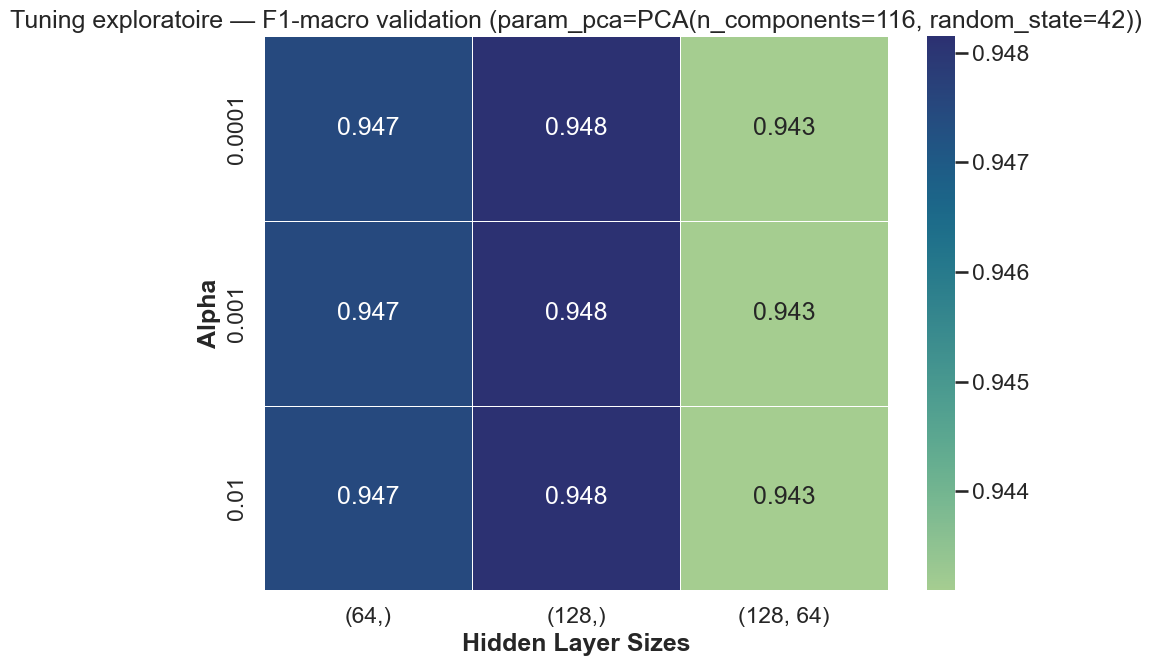

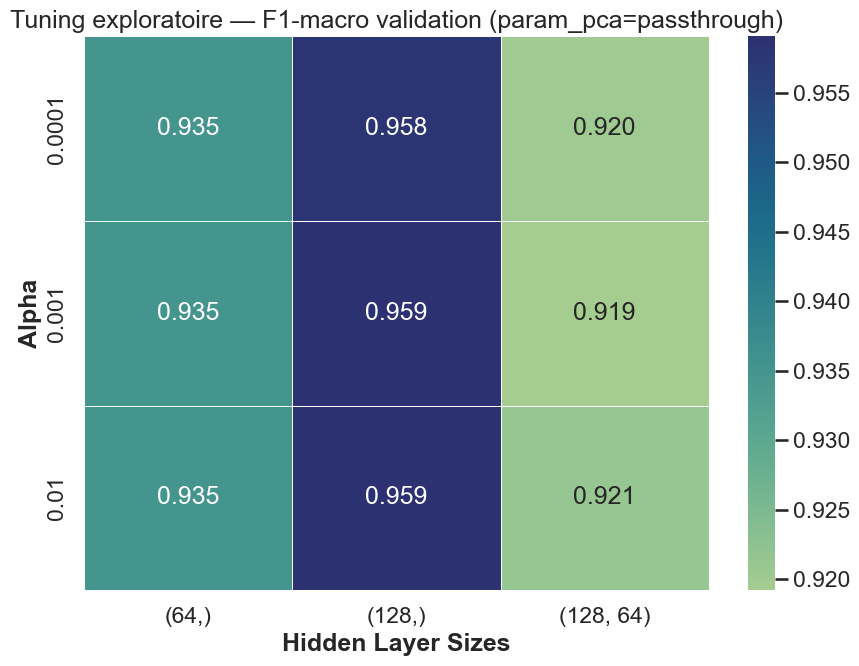

In [12]:
grid_results = tuning["grid_results"].copy()
x_axis, y_axis = spec.tuning_heatmap_axes
facet = spec.tuning_facet_column

# Heatmaps de performance uniquement — les heatmaps de gap racontent
# la meme histoire (alpha nul, (128,64) pire) et sont supprimees.
def _plot_heatmaps(data, x, y, facet_col, valeur, titre_base):
    if facet_col and facet_col in data.columns:
        for fval in sorted(data[facet_col].astype(str).unique()):
            subset = data[data[facet_col].astype(str) == fval]
            tracer_heatmap_tuning(
                subset, x=x, y=y, valeur=valeur,
                titre=f"{titre_base} ({facet_col}={fval})",
            )
            plt.show()
    else:
        tracer_heatmap_tuning(data, x=x, y=y, valeur=valeur, titre=titre_base)
        plt.show()

_plot_heatmaps(
    grid_results, x_axis, y_axis, facet,
    valeur="mean_test_f1_macro",
    titre_base="Tuning exploratoire — F1-macro validation",
)

#### Interaction PCA x Architecture

Les heatmaps revelent un resultat non trivial :

| Architecture | Sans PCA | Avec PCA | Effet PCA |
|---|---|---|---|
| `(64,)` | 0.935 | 0.947 | **+0.012** — PCA aide |
| `(128,)` | 0.959 | 0.948 | **-0.011** — PCA nuit |
| `(128,64)` | 0.920 | 0.943 | **+0.023** — PCA aide beaucoup |

**Interpretation** : la PCA agit comme une compression utile pour les reseaux
mal dimensionnes. `(64,)` manque de capacite pour extraire les bonnes
representations depuis 192 features brutes — la PCA fait ce travail a sa place.
`(128,64)` sur-apprend en haute dimension — la PCA reduit le sur-apprentissage.
En revanche, `(128,)` est bien dimensionne : il apprend directement les
representations utiles et la PCA retire de l'information sans compensation.

**Conclusion** : la PCA n'est pas universellement benefique — son utilite depend
de l'adequation entre la capacite du reseau et la dimensionnalite du probleme.

**Alpha** : les lignes de chaque heatmap sont identiques. Changing alpha de
0.0001 a 0.01 (100x) ne change pas le score. L'early stopping s'enclenche
a l'iteration ~35, avant que les poids ne grossissent suffisamment pour que
la penalite L2 ait un effet. C'est de la **regularisation implicite**.

## 5. Diagnostics du modele

Cette section regroupe les diagnostics qui racontent **comment** le MLP apprend,
**ou** il se trompe, et **a quel point** on peut lui faire confiance.

### 5.1 Capacite et generalisation

#### Learning curve

La learning curve montre l'evolution du score en fonction de la taille de l'echantillon
d'entrainement. Elle permet de diagnostiquer :

- **Underfitting** : train et validation tous les deux bas — le modele manque de capacite.
- **Overfitting** : train haut, validation bas, large gap persistant — le modele memorise sans generaliser.
- **Overfitting extreme** (petites tailles) : le MLP a ~37 000 parametres pour quelques dizaines
  d'exemples — ratio capacite/donnees inverse. Il memorise par coeur les exemples d'entrainement
  (train F1 → 1.0) mais ne generalise pas (val F1 → 0). C'est de l'overfitting par
  sous-representation des donnees, pas de l'underfitting.
- **Plateau** : les deux courbes se rejoignent et stagnent — plus de donnees n'aideraient plus.

Le MLP est evalue ici avec scaling (sans PCA) pour isoler l'effet de la taille
des donnees sur la capacite du modele.

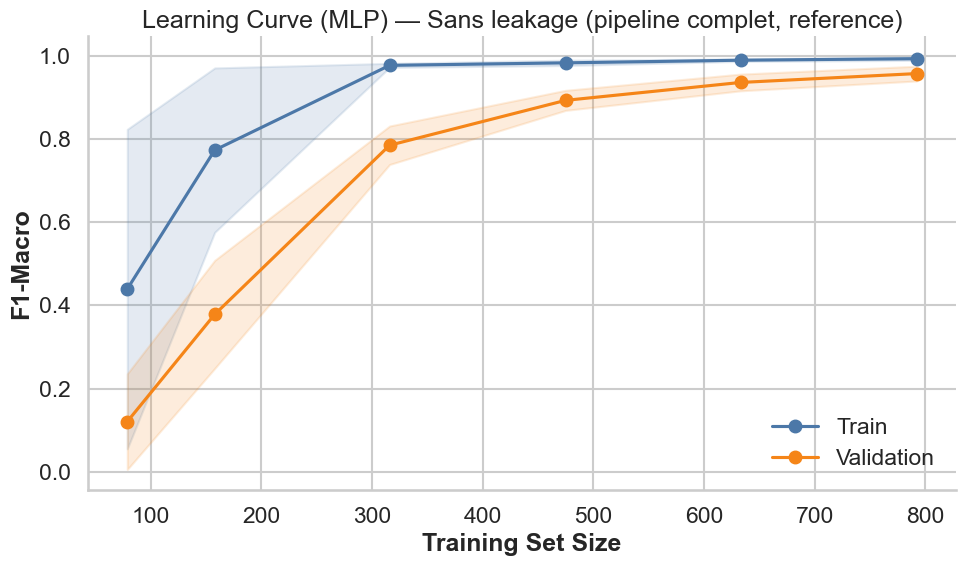

,train_size,train_mean,train_std,val_mean,val_std
0,79,0.4394,0.3846,0.1203,0.1152
1,158,0.7739,0.1979,0.3784,0.1301
2,316,0.9779,0.0048,0.7856,0.0463
3,475,0.9840,0.0065,0.8937,0.0242
4,633,0.9903,0.0029,0.9368,0.0201
5,792,0.9940,0.0041,0.9581,0.0178


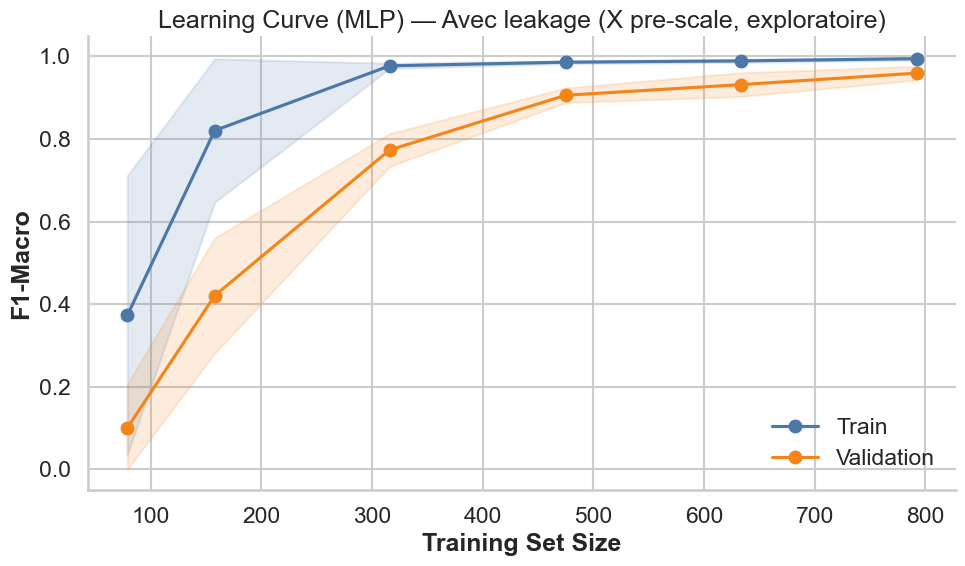

**Observation** : les deux courbes sont quasi-identiques, confirmant que le leakage du scaling sur donnees completes est negligeable sur ce dataset.

In [13]:
# --- Learning curve SANS leakage (correcte) ---
# Le pipeline complet est passe a learning_curve.
# Le scaler se fit uniquement sur les donnees d'entrainement de chaque fold.
pipeline_lc = creer_pipeline("mlp", utiliser_pca=False)

donnees_lc = compute_learning_curve(pipeline_lc, X, y)
tracer_learning_curve_mlp(
    donnees_lc,
    titre="Learning Curve (MLP) — Sans leakage (pipeline complet, reference)",
)
plt.show()

display(donnees_lc.round(4))

# --- Learning curve AVEC leakage (exploratoire, pour comparaison) ---
# X est pre-scale sur les 990 echantillons complets avant la CV.
# Conserve uniquement pour montrer que l'effet du leakage est negligeable.
pipeline_diag = creer_pipeline("mlp", utiliser_pca=False)
preprocessing = pipeline_diag[:-1]
X_scaled = pd.DataFrame(preprocessing.fit_transform(X), columns=X.columns)
estimateur_diag = pipeline_diag.named_steps["modele"]

donnees_lc_leaky = compute_learning_curve(estimateur_diag, X_scaled, y)
tracer_learning_curve_mlp(
    donnees_lc_leaky,
    titre="Learning Curve (MLP) — Avec leakage (X pre-scale, exploratoire)",
)
plt.show()

display(Markdown(
    "**Observation** : les deux courbes sont quasi-identiques, confirmant que "
    "le leakage du scaling sur donnees completes est negligeable sur ce dataset."
))

#### Loss curve (Option A — refit confirmatoire)

La loss curve est tracee sur un refit complet du MLP en utilisant
les **meilleurs hyperparametres** identifies par le grid search exploratoire.
Ce refit utilise la totalite des 990 echantillons.

**Deux courbes sont affichees :**
- **Training loss** (axe gauche) : entropie croisee minimisee par backpropagation a chaque iteration.
- **Validation accuracy** (axe droit, tirets) : score sur le holdout interne de sklearn
  (10% du jeu d'entrainement, separe avant le fit). C'est ce signal que l'early stopping
  surveille pour arreter l'entrainement.

**Ce que ce graphe permet de lire :**
- La convergence est-elle propre (loss monotone decroissante) ou oscillante ?
- A quelle iteration l'early stopping s'est-il declenche ?
- Le gap train/val indique-t-il un sur-apprentissage precoce ?

*Note methodologique* : ce fit sert uniquement au diagnostic de convergence.
Les metriques de performance proviennent exclusivement de la nested CV.

Meilleurs hyperparametres MLP : {'alpha': 0.001, 'hidden_layer_sizes': (128,)}


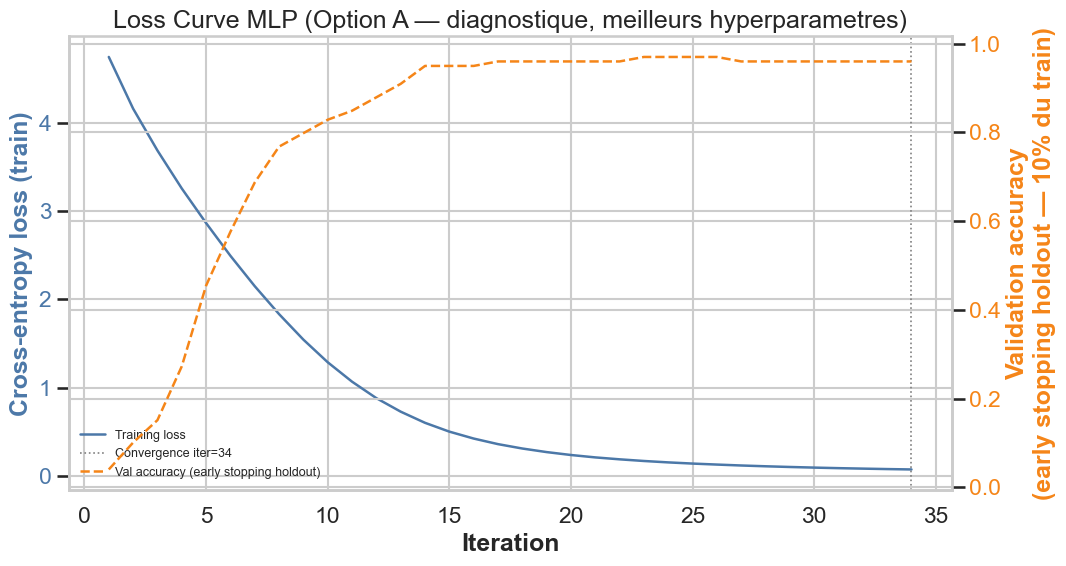

In [14]:
# Option A : extraire les meilleurs hyperparametres du grid search exploratoire
# et refitter le MLP sur la totalite des donnees preprocessees
best_params_mlp = {
    k.replace("modele__", ""): v
    for k, v in tuning["grid"].best_params_.items()
    if k.startswith("modele__")
}
print("Meilleurs hyperparametres MLP :", best_params_mlp)

donnees_loss = loss_curve_mlp(estimateur_diag, X_scaled, y, best_params=best_params_mlp)
tracer_loss_curve(
    donnees_loss,
    titre="Loss Curve MLP (Option A — diagnostique, meilleurs hyperparametres)",
)
plt.show()

### 5.2 Analyse d'erreurs

Les predictions out-of-fold de la nested CV servent de base a l'analyse d'erreurs.
Chaque echantillon est predit par un modele qui ne l'a jamais vu pendant
l'entrainement ni pendant la selection d'hyperparametres.

In [15]:
predictions = tuning["nested"]["oof_predictions"]
y_true = predictions["y_true"].to_numpy()
y_pred = predictions["y_pred"].to_numpy()

#### Paires de classes les plus confondues

,classe_vraie,classe_predite,nombre_erreurs
0,Lithocarpus_Edulis,Lithocarpus_Cleistocarpus,2
1,Magnolia_Heptapeta,Magnolia_Salicifolia,2
2,Magnolia_Salicifolia,Magnolia_Heptapeta,2
3,Arundinaria_Simonii,Eucalyptus_Glaucescens,1
4,Cercis_Siliquastrum,Fagus_Sylvatica,1
5,Cornus_Macrophylla,Cornus_Controversa,1
6,Crataegus_Monogyna,Morus_Nigra,1
7,Crataegus_Monogyna,Quercus_Coccinea,1
8,Crataegus_Monogyna,Quercus_Trojana,1
9,Eucalyptus_Glaucescens,Quercus_Alnifolia,1


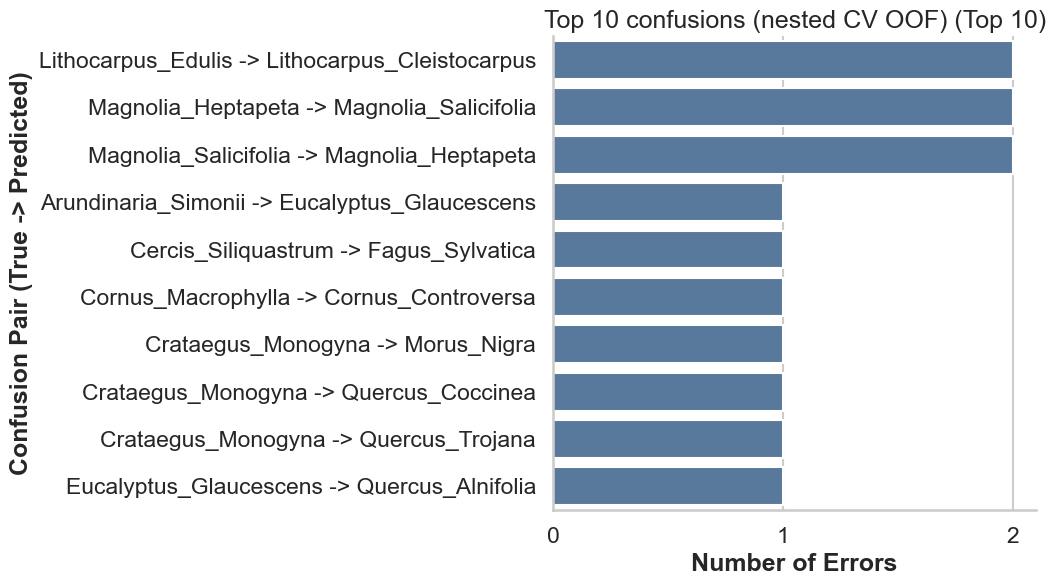

In [16]:
confusions = extraire_top_confusions(y_true, y_pred, label_encoder=label_encoder, top_n=10)
display(Markdown("#### Paires de classes les plus confondues"))
display(confusions)

tracer_top_confusions(confusions, top_n=10, titre="Top 10 confusions (nested CV OOF)")
plt.show()

#### Metriques par classe (precision, recall, F1, specificite, FPR, FNR)

,classe,precision,recall,f1,support,fpr,fnr,specificite
69,Quercus_Kewensis,0.7143,0.5000,0.5882,10,0.0020,0.5000,0.9980
40,Magnolia_Salicifolia,0.7273,0.8000,0.7619,10,0.0031,0.2000,0.9969
26,Crataegus_Monogyna,0.8750,0.7000,0.7778,10,0.0010,0.3000,0.9990
39,Magnolia_Heptapeta,0.8000,0.8000,0.8000,10,0.0020,0.2000,0.9980
81,Quercus_Suber,0.8000,0.8000,0.8000,10,0.0020,0.2000,0.9980
37,Lithocarpus_Cleistocarpus,0.7500,0.9000,0.8182,10,0.0031,0.1000,0.9969
38,Lithocarpus_Edulis,0.8889,0.8000,0.8421,10,0.0010,0.2000,0.9990
73,Quercus_Phillyraeoides,0.8889,0.8000,0.8421,10,0.0010,0.2000,0.9990
68,Quercus_Infectoria_sub,0.8889,0.8000,0.8421,10,0.0010,0.2000,0.9990
28,Eucalyptus_Glaucescens,0.8182,0.9000,0.8571,10,0.0020,0.1000,0.9980


#### Classes les plus difficiles (recall le plus bas)

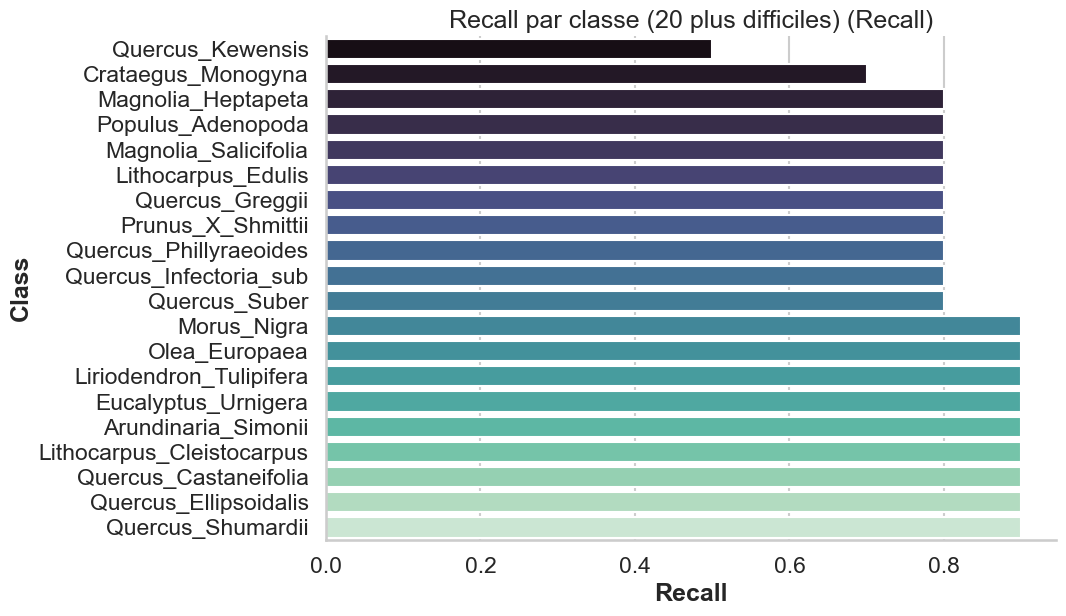

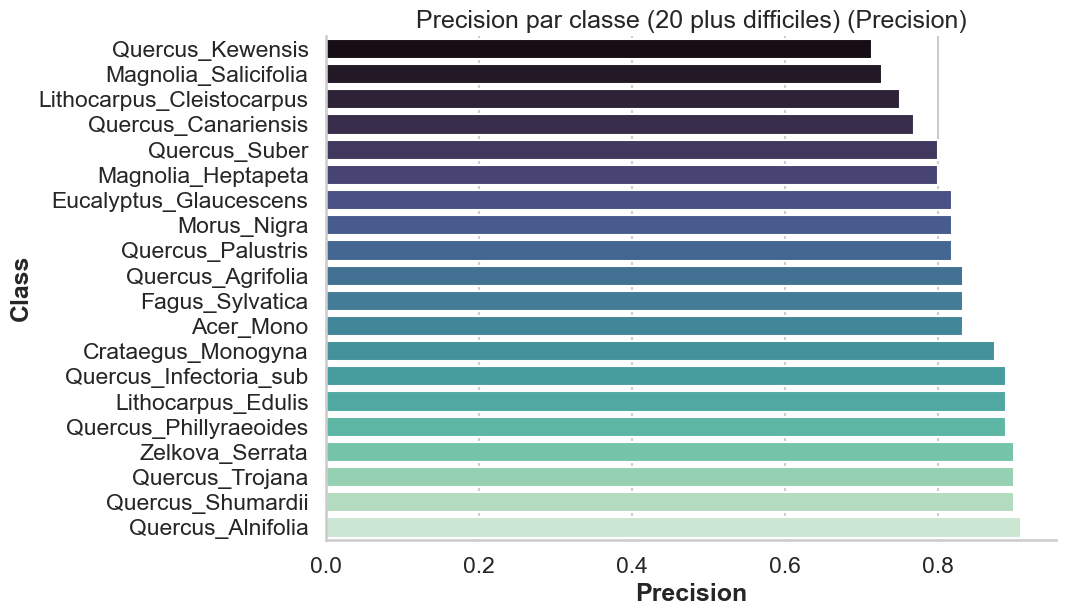

In [17]:
metriques_classes = calculer_metriques_classes_depuis_predictions(predictions, label_encoder)

display(Markdown("#### Metriques par classe (precision, recall, F1, specificite, FPR, FNR)"))
display(
    metriques_classes
    .sort_values("f1", ascending=True)
    .head(15)
    .round(4)
)

display(Markdown("#### Classes les plus difficiles (recall le plus bas)"))

tracer_metrique_par_classe(
    metriques_classes,
    metrique="recall",
    top_n=20,
    ordre="asc",
    titre="Recall par classe (20 plus difficiles)",
)
plt.show()

tracer_metrique_par_classe(
    metriques_classes,
    metrique="precision",
    top_n=20,
    ordre="asc",
    titre="Precision par classe (20 plus difficiles)",
)
plt.show()

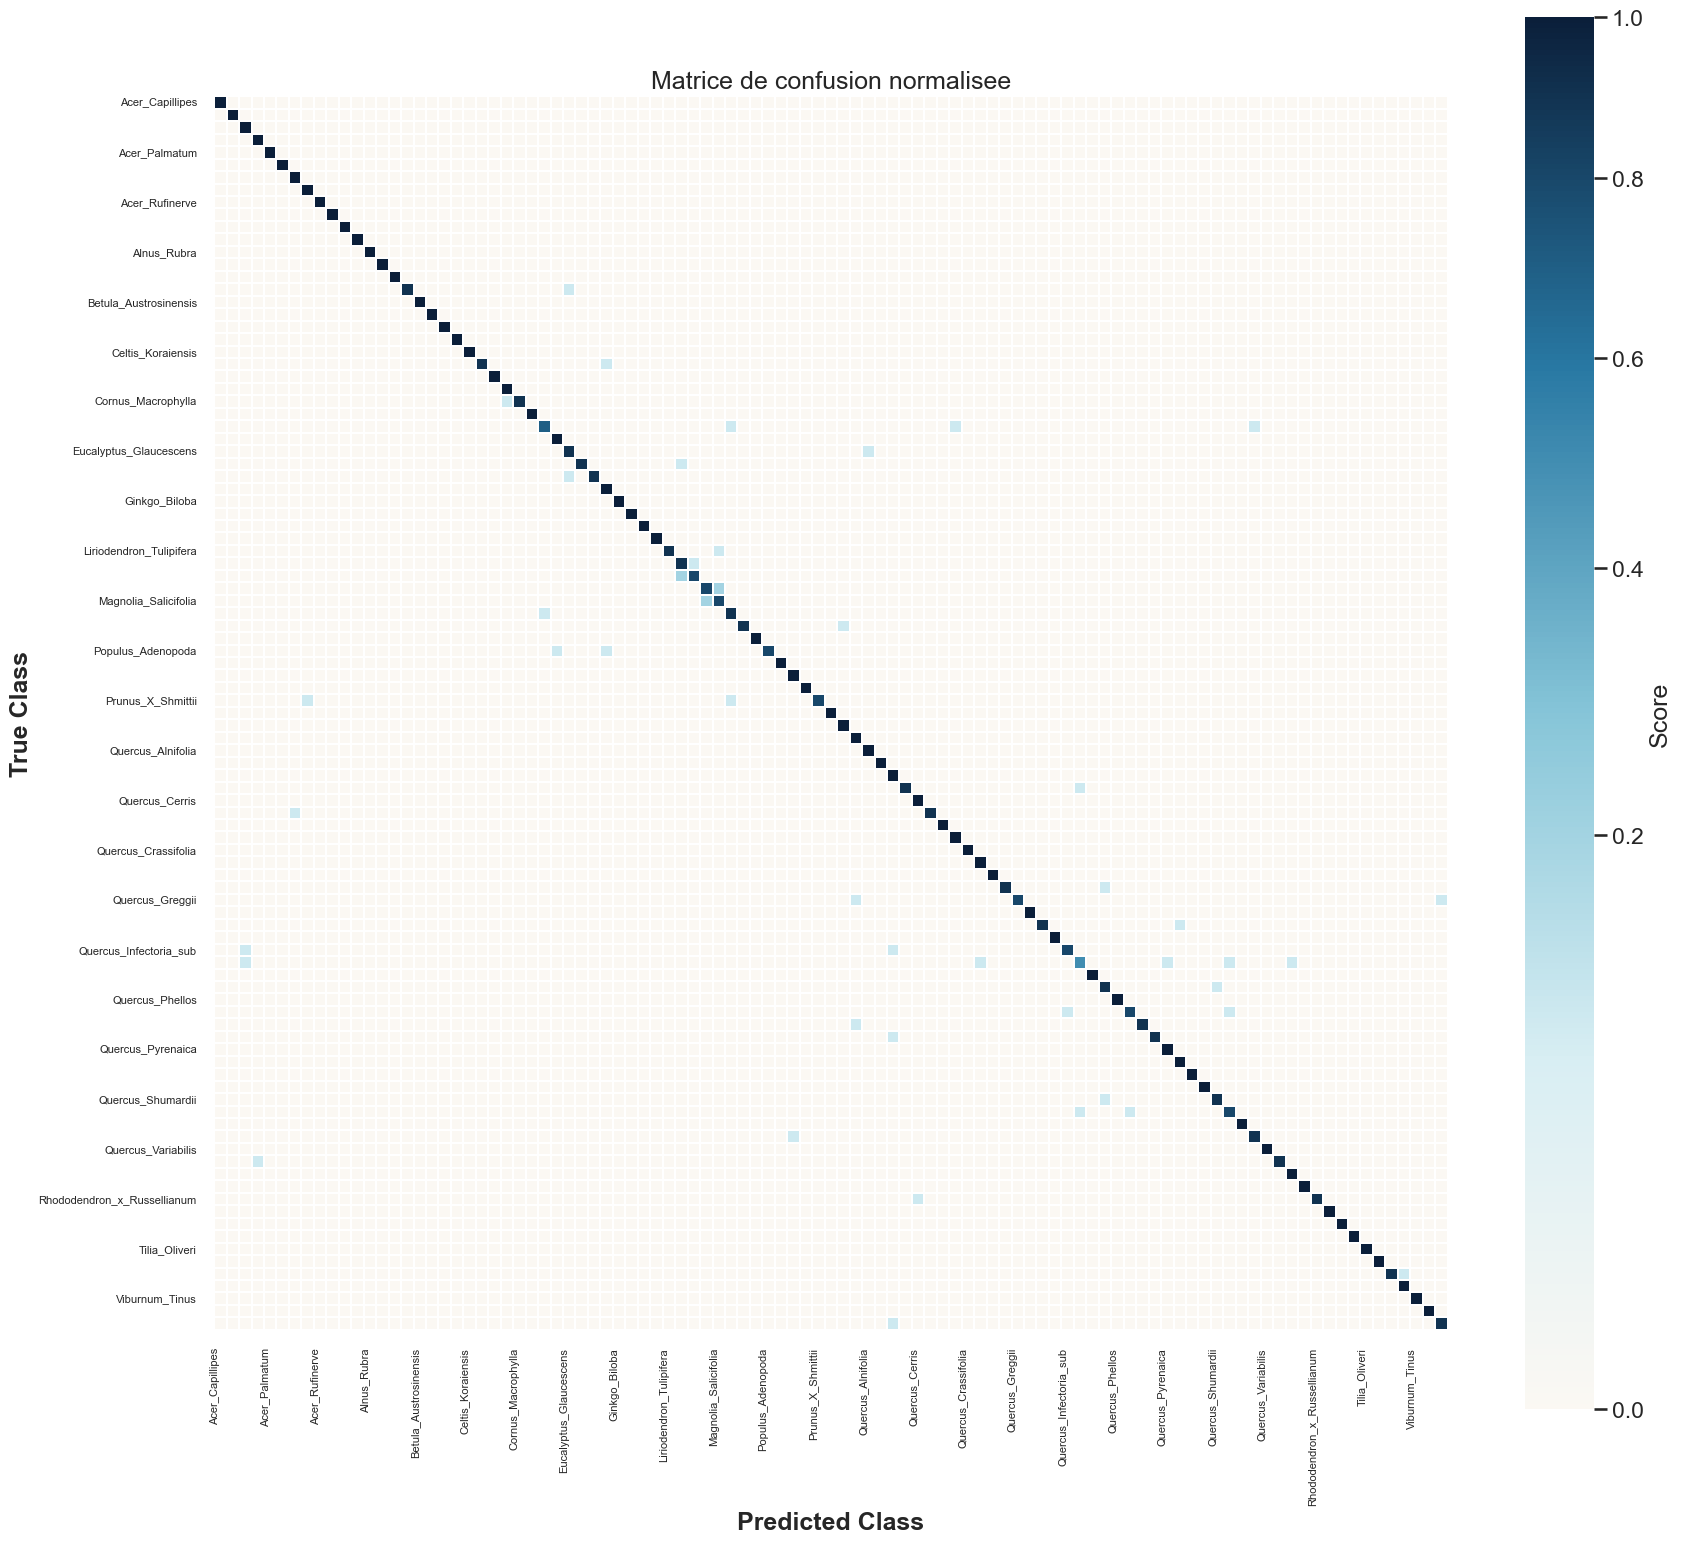

In [18]:
mat_norm = construire_matrice_confusion(
    y_true, y_pred, label_encoder=label_encoder, normalize="true",
)
tracer_matrice_confusion(mat_norm, titre="Matrice de confusion normalisee")
plt.show()

### 5.3 Analyse de confiance

Le MLP produit des probabilites via softmax. Cette section mesure si ces probabilites
sont fiables : un modele bien calibre qui annonce 80 % de confiance devrait avoir raison
80 % du temps.

Le **Brier score** mesure la qualite globale de calibration (plus bas = mieux).
Le **top-k accuracy** mesure si la bonne classe figure parmi les k plus probables.

In [19]:
probas = tuning["nested"]["oof_probabilities"]
assert probas is not None, "Le MLP doit produire des probabilites OOF"

In [20]:
topk = calculer_top_k_accuracies(probas, ks=(1, 3, 5, 10))
display(Markdown("#### Top-k accuracy"))
display(pd.DataFrame([topk]).round(4))

#### Top-k accuracy

,top_1_accuracy,top_3_accuracy,top_5_accuracy,top_10_accuracy
0,0.9505,0.9949,0.9980,1.0000


In [21]:
stats_conf = calculer_statistiques_confiance(probas)
display(Markdown("#### Indicateurs de confiance"))
display(pd.DataFrame([stats_conf]).round(4))

#### Indicateurs de confiance

,confiance_moyenne,confiance_moyenne_correctes,confiance_moyenne_erreurs,proportion_erreurs_confiance_sup_0_5,proportion_erreurs_confiance_inf_0_3
0,0.7103,0.7302,0.3282,0.1020,0.4490


In [22]:
brier = calculer_brier_score_multiclasse(probas)
print(f"Brier score multiclasse : {brier:.4f}")
print(f"(Plus bas = meilleures probabilites)")

Brier score multiclasse : 0.1603
(Plus bas = meilleures probabilites)


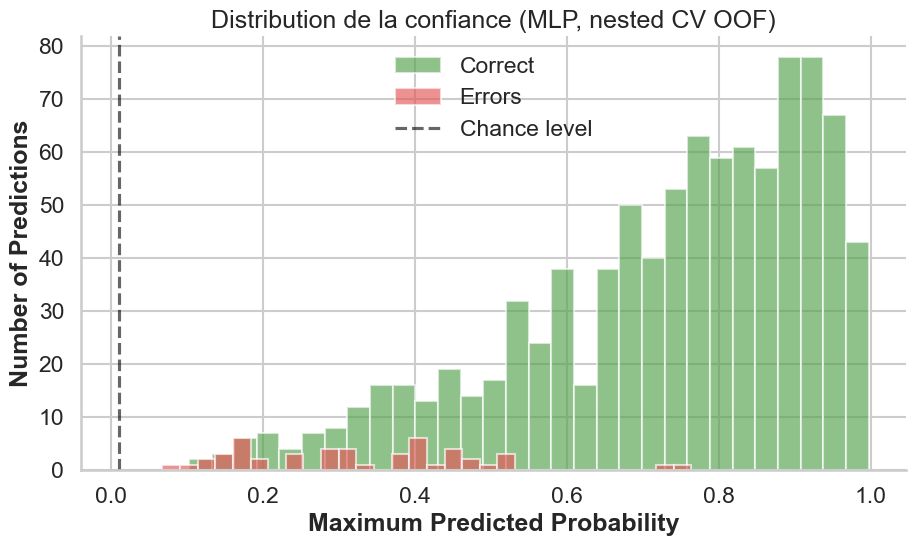

In [23]:
tracer_histogramme_confiance(probas, titre="Distribution de la confiance (MLP, nested CV OOF)")
plt.show()

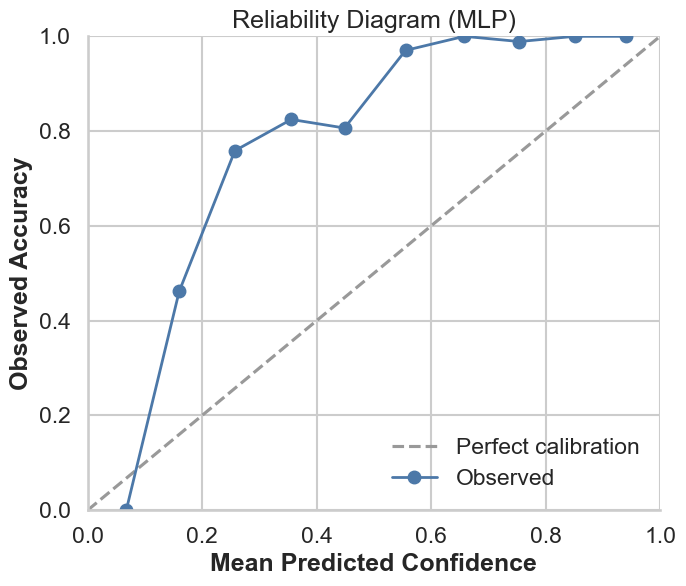

In [24]:
tracer_reliability_diagram(probas, titre="Reliability Diagram (MLP)")
plt.show()

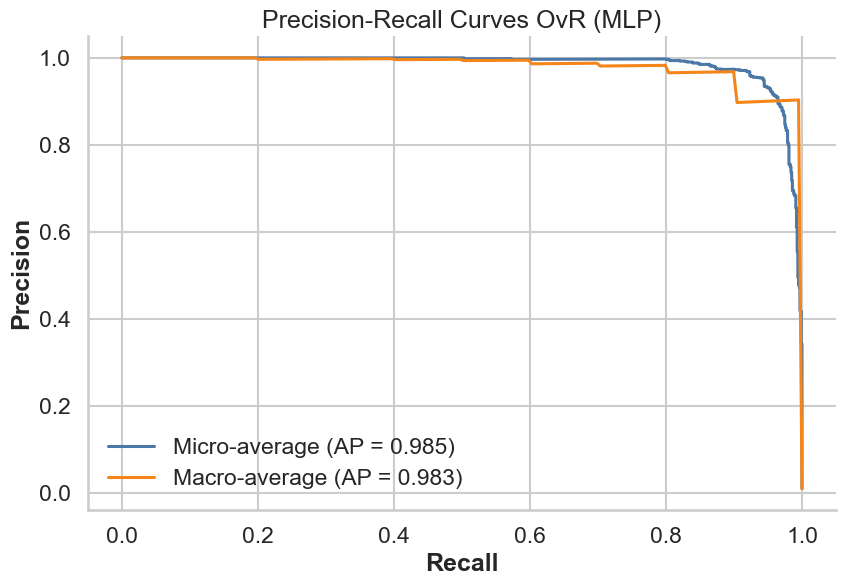

In [25]:

tracer_courbes_precision_rappel_ovr(probas, titre="Precision-Recall Curves OvR (MLP)")
plt.show()

### 5.4 Interpretation scientifique

Cette section repond aux questions posees en introduction.
Les cellules ci-dessous calculent les reponses factuelles ;
l'interpretation narrative appartient au rapport final.

In [26]:
d = {r.variante: r for r in resultats_untuned}
tuned_f1 = tuning["metrics"]["val_f1_macro_mean"]

reponses = []

# H1
if "default" in d and "scaled_only" in d:
    f1_def = d["default"].val_f1_macro_mean
    f1_sc  = d["scaled_only"].val_f1_macro_mean
    reponses.append({
        "hypothese": "H1 - default faible sans scaling",
        "resultat": f"default={f1_def:.4f}  scaled_only={f1_sc:.4f}",
        "verdict": "Confirmee" if f1_def < f1_sc - 0.02 else "Non confirmee",
    })

# H2
if "default" in d and "scaled_only" in d:
    gain_sc = d["scaled_only"].val_f1_macro_mean - d["default"].val_f1_macro_mean
    reponses.append({
        "hypothese": "H2 - le scaling apporte un gain majeur",
        "resultat": f"gain = +{gain_sc:.4f}",
        "verdict": "Confirmee" if gain_sc > 0.05 else "Partielle" if gain_sc > 0.01 else "Non confirmee",
    })

# H3
if "scaled_only" in d and "scaled_pca" in d:
    delta_pca = d["scaled_pca"].val_f1_macro_mean - d["scaled_only"].val_f1_macro_mean
    reponses.append({
        "hypothese": "H3 - la PCA aide ou retire de l'information",
        "resultat": f"delta PCA = {delta_pca:+.4f}",
        "verdict": "Aide" if delta_pca > 0.01 else "Neutre" if abs(delta_pca) <= 0.01 else "Nuit",
    })

# H4 — ablation capacite : (64,) vs (128,) vs (128,64)
# Le gain de tuning compare nested CV vs simple CV — protocoles differents,
# un gain negatif est un artefact attendu, pas une vraie degradation.
# L'ablation sur les architectures est la vraie reponse a H4.
best_untuned_f1 = max(r.val_f1_macro_mean for r in resultats_untuned)
gain_tuning = tuned_f1 - best_untuned_f1

# Lire le classement des architectures dans les heatmaps (grid search interne)
arch_col = "param_modele__hidden_layer_sizes"
if arch_col in tuning["grid_results"].columns:
    arch_perf = (
        tuning["grid_results"]
        .groupby(arch_col)["mean_test_f1_macro"]
        .mean()
        .sort_values(ascending=False)
    )
    meilleure_arch = str(arch_perf.index[0])
    arch_summary = "  ".join(f"{str(k)}={v:.4f}" for k, v in arch_perf.items())
else:
    arch_summary = "non disponible"
    meilleure_arch = "(128,)"

reponses.append({
    "hypothese": "H4 - ablation capacite : (64,) vs (128,) vs (128,64)",
    "resultat": arch_summary,
    "verdict": "Confirmee" if meilleure_arch == "(128,)" else "Partielle",
})

display(Markdown("#### Verdict sur les hypotheses"))
display(pd.DataFrame(reponses))

#### Verdict sur les hypotheses

,hypothese,resultat,verdict
0,H1 - default faible sans scaling,default=0.3312 scaled_only=0.9581,Confirmee
1,H2 - le scaling apporte un gain majeur,gain = +0.6269,Confirmee
2,H3 - la PCA aide ou retire de l'information,delta PCA = -0.0100,Neutre
3,"H4 - ablation capacite : (64,) vs (128,) vs (1...","(128,)=0.9534 (64,)=0.9413 (128, 64)=0.9317",Confirmee


In [27]:
gap_best = None
for r in resultats_untuned:
    if r.val_f1_macro_mean == best_untuned_f1:
        gap_best = r.generalization_gap_f1_macro
        break

nested_std = tuning["metrics"]["val_f1_macro_std"]

resume = {
    "f1_tuned (mean +/- std)": f"{tuned_f1:.4f} +/- {nested_std:.4f}",
    "f1_untuned_best": round(best_untuned_f1, 4),
    "gain_tuning": round(gain_tuning, 4),
    "gap_f1_meilleure_variante_untuned": round(gap_best, 4),
    "brier_score": round(brier, 4),
    "top_1_accuracy": round(topk.get("top_1_accuracy"), 4),
    "top_5_accuracy": round(topk.get("top_5_accuracy"), 4),
    "confiance_moyenne": round(stats_conf["confiance_moyenne"], 4),
    "confiance_erreurs": round(stats_conf["confiance_moyenne_erreurs"], 4),
    "temps_tuning_s": round(tuning["exploratory_tuning_seconds"], 1),
}
display(Markdown("#### Resume chiffre"))
display(pd.DataFrame([resume]).T.rename(columns={0: "valeur"}))

#### Resume chiffre

,valeur
f1_tuned (mean +/- std),0.9455 +/- 0.0162
f1_untuned_best,0.9581
gain_tuning,-0.0127
gap_f1_meilleure_variante_untuned,0.0359
brier_score,0.1603
top_1_accuracy,0.9505
top_5_accuracy,0.9980
confiance_moyenne,0.7103
confiance_erreurs,0.3282
temps_tuning_s,35.6000


## 6. Resume des artefacts exportes

Les fichiers ci-dessous ont ete produits pendant l'execution de ce notebook.
Ils servent de preuve pour le rapport et d'entree pour le notebook 08 (comparaison globale).

In [28]:
artefacts = pd.DataFrame([
    {"artefact": "metrics (untuned)", "detail": f"{len(resultats_untuned)} variantes sauvegardees"},
    {"artefact": "metrics (tuned)", "path": str(tuning["metrics_path"])},
    {"artefact": "predictions (tuned)", "path": str(tuning["predictions_path"])},
    {"artefact": "grid_search", "path": str(tuning["grid_path"])},
    {
        "artefact": "probabilities (tuned)",
        "path": str(tuning["probabilities_path"]) if tuning["probabilities_path"] else "n/a",
    },
])
display(artefacts)

,artefact,detail,path
0,metrics (untuned),3 variantes sauvegardees,NaN
1,metrics (tuned),NaN,C:\Users\moulo\Documents\Projet_Session_IFT712...
2,predictions (tuned),NaN,C:\Users\moulo\Documents\Projet_Session_IFT712...
3,grid_search,NaN,C:\Users\moulo\Documents\Projet_Session_IFT712...
4,probabilities (tuned),NaN,C:\Users\moulo\Documents\Projet_Session_IFT712...
